# Customer Churn Prediction — Real Telco Data

## Executive summary
Retaining a customer is far cheaper than winning a new one. This notebook predicts which customers are about to **churn** (cancel their subscription) so a retention team can intervene *before* they leave — and, just as importantly, explains *why* each customer is at risk.

**Data:** the real **[Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)** dataset — **7,043 real customers**, 26.5% of whom churned. (Telecom is the canonical churn benchmark; the same approach transfers directly to banking, SaaS and any subscription business.)

## Headline results (held-out test set)
| Model | Churn recall | Churn precision | ROC-AUC | PR-AUC |
|-------|-------------:|----------------:|--------:|-------:|
| **Logistic Regression (balanced)** | **0.78** | 0.50 | **0.842** | 0.633 |
| XGBoost (`scale_pos_weight`) | 0.76 | 0.52 | 0.839 | **0.657** |
| Random Forest (balanced) | 0.66 | 0.56 | 0.827 | 0.618 |

**5-fold CV ROC-AUC (Logistic Regression): 0.845 ± 0.013** — stable.

**💡 Business impact:** rank customers by churn risk and target the **top 20% → you reach ~50% of everyone who will actually churn** (top 30% → ~65%), instead of the 20–30% a blind campaign would reach.

> **The accuracy trap (read this):** 73.5% of customers *don't* churn, so a model that predicts "nobody churns" is 73.5% accurate and completely useless. That's why this project optimises **recall and ROC-AUC**, not accuracy — a deliberate, defensible choice.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                             precision_score, f1_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb, shap
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
DATA = Path("../data"); IMG = Path("../images"); IMG.mkdir(exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the real data

In [2]:
df = pd.read_csv(DATA / "telco_churn.csv")
print(f"{df.shape[0]:,} customers x {df.shape[1]} columns | churn rate {(df['Churn']=='Yes').mean():.1%}")
df.head(3)

7,043 customers x 21 columns | churn rate 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Data cleaning
Two real-world quirks:
- **`TotalCharges` is stored as text** with **11 blank values** — these are brand-new customers (`tenure = 0`) who haven't been billed yet. We coerce to numeric and set them to £0.
- We drop the `customerID` (not predictive) and encode the target `Churn` as 1/0.

In [3]:
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_blank = df["TotalCharges"].isna().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print(f"Filled {n_blank} blank TotalCharges (tenure-0 new customers) with 0.")
print("Majority-class ('no churn') baseline accuracy:", f"{1 - df['Churn'].mean():.1%}")

Filled 11 blank TotalCharges (tenure-0 new customers) with 0.
Majority-class ('no churn') baseline accuracy: 73.5%


## 3. Exploratory data analysis — where does churn concentrate?

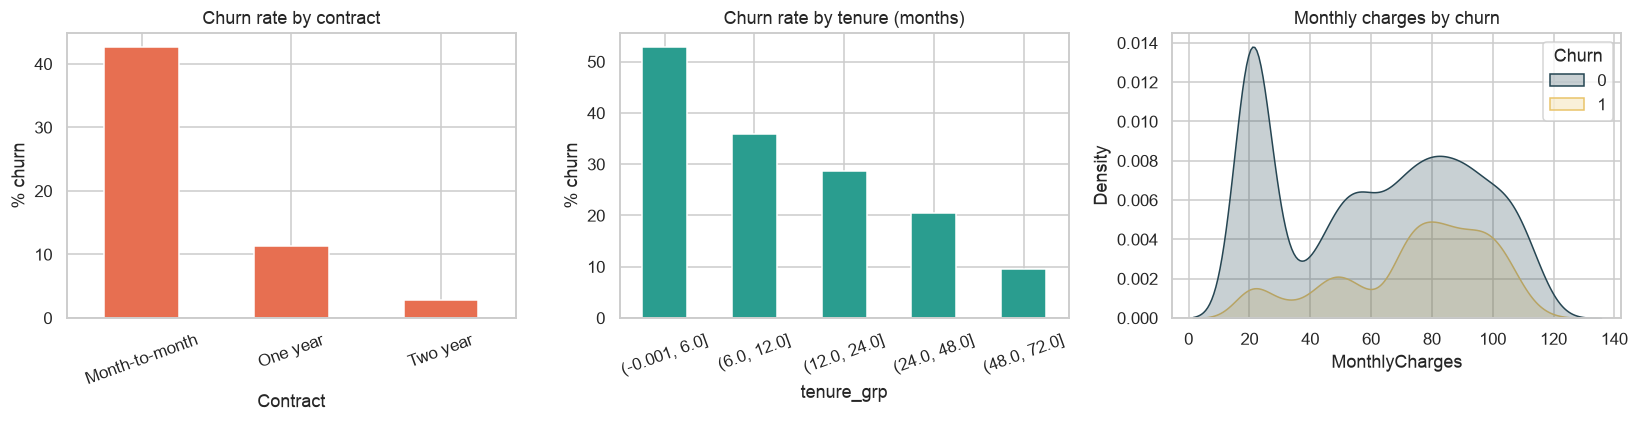

Month-to-month + short-tenure + high monthly charges = the danger zone.


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# churn by contract
(df.groupby("Contract")["Churn"].mean()*100).plot.bar(ax=ax[0], color="#e76f51")
ax[0].set_title("Churn rate by contract"); ax[0].set_ylabel("% churn"); ax[0].tick_params(axis='x', rotation=20)
# churn by tenure bucket
df["tenure_grp"] = pd.cut(df["tenure"], [0,6,12,24,48,72], include_lowest=True)
(df.groupby("tenure_grp")["Churn"].mean()*100).plot.bar(ax=ax[1], color="#2a9d8f")
ax[1].set_title("Churn rate by tenure (months)"); ax[1].set_ylabel("% churn"); ax[1].tick_params(axis='x', rotation=20)
# monthly charges distribution by churn
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, ax=ax[2], palette=["#264653","#e9c46a"])
ax[2].set_title("Monthly charges by churn")
plt.tight_layout(); plt.savefig(IMG / "eda_churn.png", bbox_inches="tight"); plt.show()
df = df.drop(columns=["tenure_grp"])
print("Month-to-month + short-tenure + high monthly charges = the danger zone.")

## 4. Feature preparation
One-hot encode the categorical service/contract fields and standardise the numeric ones. This yields ~30 features.

In [5]:
y = df["Churn"]; X = df.drop(columns=["Churn"])
num = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
cat = [c for c in X.columns if c not in num]
X = pd.get_dummies(X, columns=cat, drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_tr[num] = scaler.fit_transform(X_tr[num]); X_te[num] = scaler.transform(X_te[num])
print(f"{X.shape[1]} features | train {len(X_tr):,} | test {len(X_te):,}")

30 features | train 5,634 | test 1,409


## 5. Model comparison
Because churn is the minority class, every model is told to **weight the churn class up** (`class_weight='balanced'` / `scale_pos_weight`). We judge on **churn recall, ROC-AUC and PR-AUC** — not accuracy.

In [6]:
def report(name, model):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]; pred = (proba >= 0.5).astype(int)
    row = dict(model=name, accuracy=(pred==y_te).mean(), recall=recall_score(y_te,pred),
               precision=precision_score(y_te,pred), f1=f1_score(y_te,pred),
               roc_auc=roc_auc_score(y_te,proba), pr_auc=average_precision_score(y_te,proba))
    return model, proba, row

spw = (y_tr==0).sum()/(y_tr==1).sum()
logreg, p_lr, r1 = report("Logistic Regression", LogisticRegression(max_iter=2000, class_weight="balanced"))
rf,     p_rf, r2 = report("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1))
xgbm,   p_xgb, r3 = report("XGBoost", xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="logloss", random_state=42))
pd.DataFrame([r1,r2,r3]).set_index("model").round(3)

,accuracy,recall,precision,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.739,0.783,0.505,0.614,0.842,0.633
Random Forest,0.771,0.660,0.558,0.605,0.827,0.618
XGBoost,0.748,0.762,0.517,0.616,0.839,0.657


In [7]:
cv = cross_val_score(LogisticRegression(max_iter=2000, class_weight="balanced"),
                     X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc")
print(f"Logistic Regression 5-fold CV ROC-AUC: {cv.mean():.3f} +/- {cv.std():.3f}")

Logistic Regression 5-fold CV ROC-AUC: 0.845 +/- 0.013


### ROC & precision-recall curves, and the confusion matrix
Logistic Regression is our pick: it matches the ensembles on ROC-AUC while staying **fully interpretable** (Section 6).

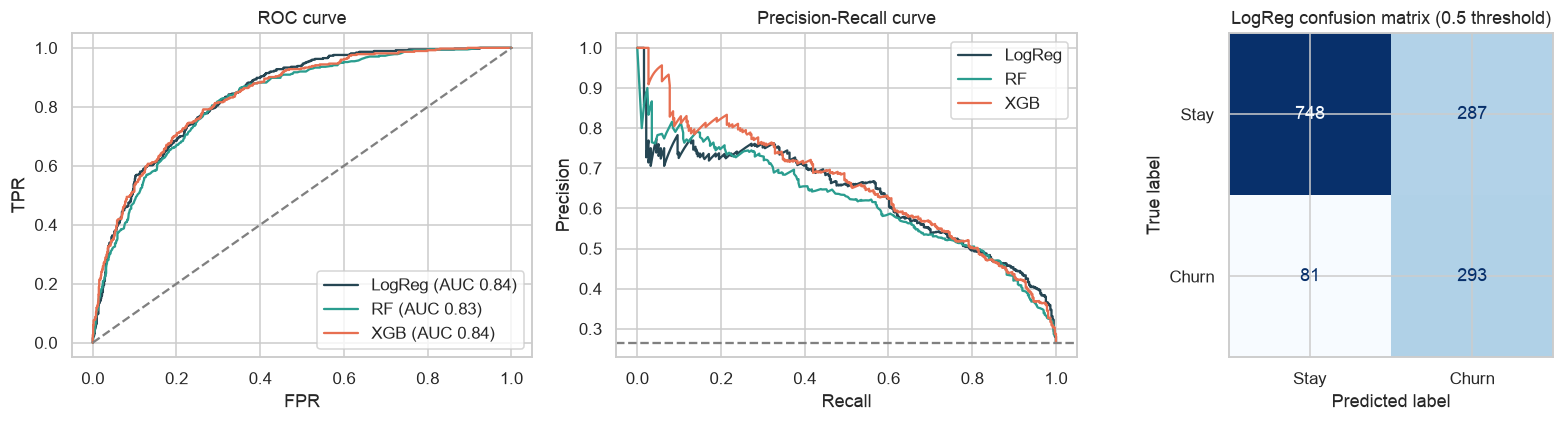

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for p, name, c in [(p_lr,"LogReg","#264653"), (p_rf,"RF","#2a9d8f"), (p_xgb,"XGB","#e76f51")]:
    fpr, tpr, _ = roc_curve(y_te, p); ax[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te,p):.2f})", color=c)
    pr, rc, _ = precision_recall_curve(y_te, p); ax[1].plot(rc, pr, label=name, color=c)
ax[0].plot([0,1],[0,1],"--",color="grey"); ax[0].set_title("ROC curve"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].axhline(y_te.mean(), ls="--", color="grey"); ax[1].set_title("Precision-Recall curve"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
ConfusionMatrixDisplay(confusion_matrix(y_te, (p_lr>=0.5).astype(int)), display_labels=["Stay","Churn"]).plot(ax=ax[2], colorbar=False, cmap="Blues")
ax[2].set_title("LogReg confusion matrix (0.5 threshold)")
plt.tight_layout(); plt.savefig(IMG / "model_curves.png", bbox_inches="tight"); plt.show()

## 6. Why customers churn — interpretable drivers
Logistic-regression coefficients read directly as churn risk: positive = raises churn, negative = protects. These match domain knowledge, which is exactly what you want a stakeholder to see.

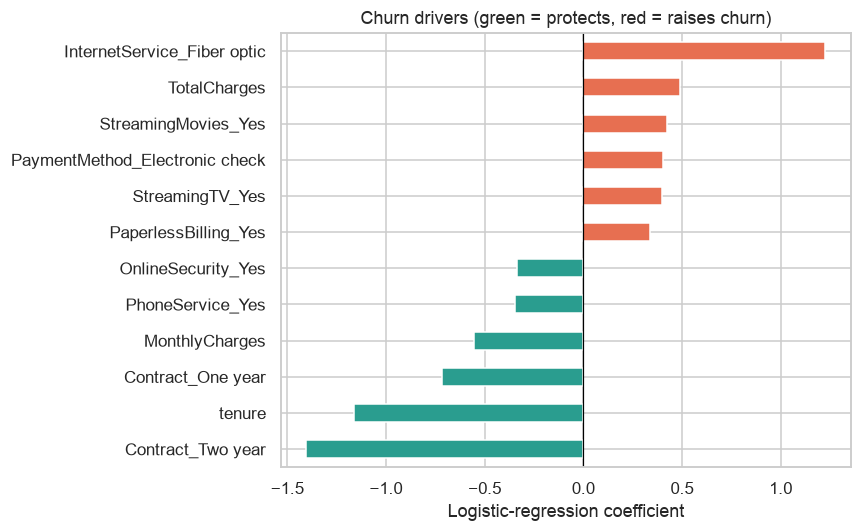

Protective: two-year contract, longer tenure, one-year contract, online security.
Risk-raising: fiber-optic internet, electronic-check payment, paperless billing, streaming add-ons.


In [9]:
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
top = pd.concat([coef.head(6), coef.tail(6)])
plt.figure(figsize=(8,5))
colors = ["#2a9d8f" if v < 0 else "#e76f51" for v in top.values]
top.plot.barh(color=colors)
plt.axvline(0, color="black", lw=0.8); plt.title("Churn drivers (green = protects, red = raises churn)")
plt.xlabel("Logistic-regression coefficient")
plt.tight_layout(); plt.savefig(IMG / "churn_drivers.png", bbox_inches="tight"); plt.show()
print("Protective: two-year contract, longer tenure, one-year contract, online security.")
print("Risk-raising: fiber-optic internet, electronic-check payment, paperless billing, streaming add-ons.")

### Bonus: SHAP on the XGBoost model
Cross-checking the interpretable coefficients with a tree model's SHAP values — they agree on what matters.

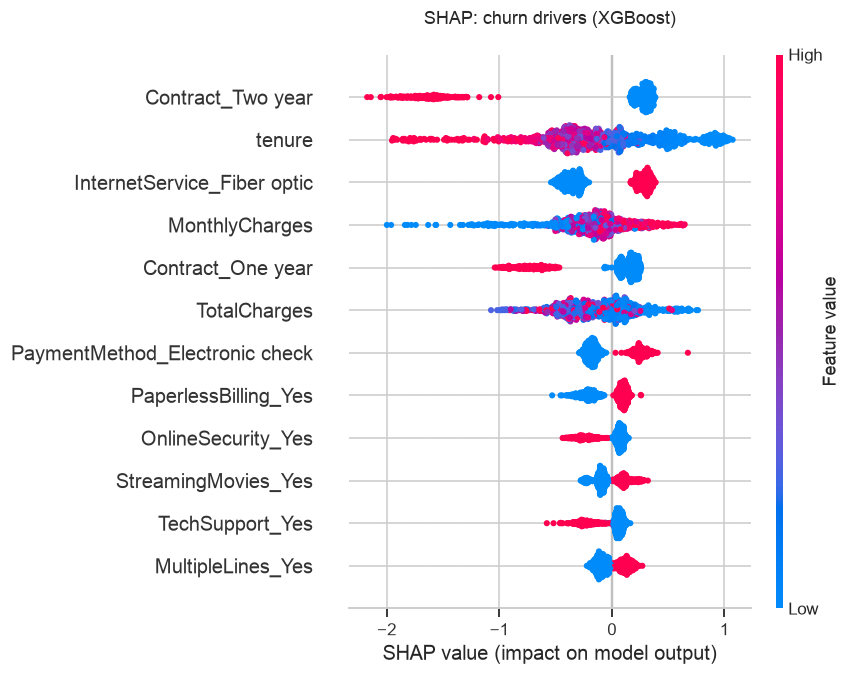

In [10]:
explainer = shap.TreeExplainer(xgbm)
Xs = X_te.sample(min(1000, len(X_te)), random_state=42)
sv = explainer.shap_values(Xs)
plt.figure(); shap.summary_plot(sv, Xs, show=False, max_display=12)
plt.title("SHAP: churn drivers (XGBoost)", pad=20)
plt.tight_layout(); plt.savefig(IMG / "shap_summary.png", bbox_inches="tight"); plt.show()

## 7. Business impact — the retention campaign
A retention budget can only reach so many customers. If we rank everyone by predicted churn risk and work down the list, how many real churners do we reach for a given budget?

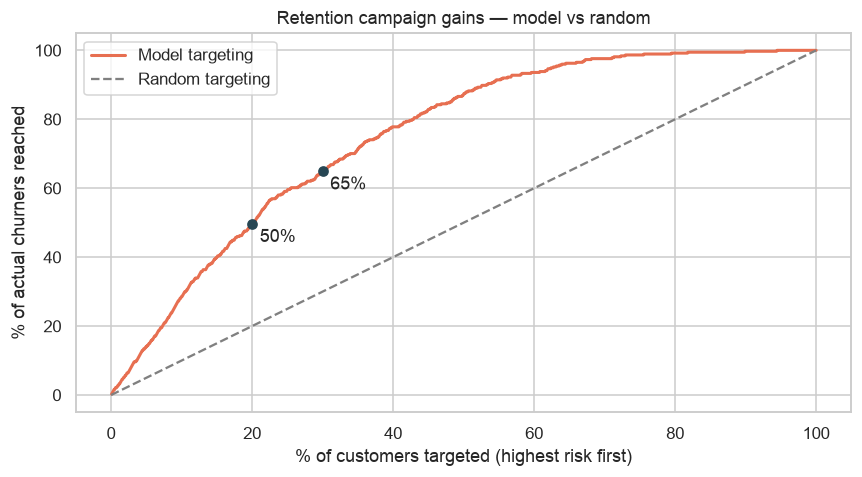

Target top 10%  ->  reach 28% of churners
Target top 20%  ->  reach 50% of churners
Target top 30%  ->  reach 65% of churners


In [11]:
res = pd.DataFrame({"actual": y_te.values, "proba": p_lr}).sort_values("proba", ascending=False).reset_index(drop=True)
res["cum_churn_pct"] = res["actual"].cumsum() / res["actual"].sum() * 100
res["pct_targeted"] = (res.index + 1) / len(res) * 100
plt.figure(figsize=(8,4.5))
plt.plot(res["pct_targeted"], res["cum_churn_pct"], color="#e76f51", lw=2, label="Model targeting")
plt.plot([0,100],[0,100], "--", color="grey", label="Random targeting")
for pct in (20, 30):
    v = res.loc[(res["pct_targeted"]-pct).abs().idxmin(), "cum_churn_pct"]
    plt.scatter([pct],[v], color="#264653", zorder=5); plt.annotate(f"{v:.0f}%", (pct, v), textcoords="offset points", xytext=(5,-12))
plt.xlabel("% of customers targeted (highest risk first)"); plt.ylabel("% of actual churners reached")
plt.title("Retention campaign gains — model vs random"); plt.legend()
plt.tight_layout(); plt.savefig(IMG / "retention_gains.png", bbox_inches="tight"); plt.show()
for pct in (10,20,30):
    n=int(len(res)*pct/100); print(f"Target top {pct}%  ->  reach {res.head(n)['actual'].sum()/res['actual'].sum()*100:.0f}% of churners")

## 8. Conclusion, limitations & next steps

**What works:** on real, imbalanced data, a well-regularised **Logistic Regression** catches **~78% of churners** with a **0.84 ROC-AUC** (stable under cross-validation), while remaining fully explainable — and a tree-based SHAP analysis agrees on the drivers. Ranking customers by risk lets a retention team **reach half of all churners by contacting just the riskiest 20%**.

**Honest limitations:**
- Accuracy (~74%) is *deliberately* not the objective — it barely beats the 73.5% majority baseline, which is the whole point.
- Precision at the default 0.5 threshold is ~0.50; the operating threshold should be set by the economics of a retention offer vs. a lost customer (a threshold-tuning exercise).
- The dataset is a single snapshot; no temporal/behavioural trend features are available.

**Next steps:** cost-based threshold optimisation, uplift modelling (who is *persuadable*, not just at-risk), and a Streamlit tool that scores a customer and shows their top churn drivers.

---
### 🎤 Interview talking points
- *"Your accuracy is only 74% — is that good?"* It's a trap: 73.5% of customers don't churn, so accuracy is meaningless here. I optimise recall and ROC-AUC (0.84).
- *"Why Logistic Regression over XGBoost?"* Equal ROC-AUC, but LogReg is transparent — the coefficients are the churn drivers, which stakeholders trust. XGBoost + SHAP confirms them.
- *"How would you act on this?"* Rank by risk and target the top 20% to reach ~50% of churners; set the threshold from the cost of an offer vs. a lost customer.
- *"How did you handle the messy TotalCharges column?"* 11 blanks were tenure-0 new customers → £0, not random missingness.
